In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob

In [2]:
import pandas as pd

df = pd.read_csv("vaccination_all_tweets.csv")

print(df.shape)
print(df.columns)
df.head()

(228207, 16)
Index(['id', 'user_name', 'user_location', 'user_description', 'user_created',
       'user_followers', 'user_friends', 'user_favourites', 'user_verified',
       'date', 'text', 'hashtags', 'source', 'retweets', 'favorites',
       'is_retweet'],
      dtype='object')


,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet
0,1340539111971516416,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,Same folks said daikon paste could treat a cyt...,['PfizerBioNTech'],Twitter for Android,0,0,False
1,1338158543359250433,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,834,666,178,False,2020-12-13 16:27:13,While the world has been on the wrong side of ...,NaN,Twitter Web App,1,1,False
2,1337858199140118533,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,0,0,False
3,1337855739918835717,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,49165,3933,21853,True,2020-12-12 20:23:59,"Facts are immutable, Senator, even when you're...",NaN,Twitter Web App,446,2129,False
4,1337854064604966912,Citizen News Channel,NaN,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,152,580,1473,False,2020-12-12 20:17:19,Explain to me again why we need a vaccine @Bor...,"['whereareallthesickpeople', 'PfizerBioNTech']",Twitter for iPhone,0,0,False


We need timestamps for temporal diffusion analysis. This creates an agent-level attribute useful later in ABM.

In [3]:
df['date'] = pd.to_datetime(df['date'])
df['user_created'] = pd.to_datetime(df['user_created'])

df['account_age_days'] = (df['date'] - df['user_created']).dt.days

In [4]:
df = df.drop_duplicates()

df = df[df['text'].notna()]
df = df.reset_index(drop=True)

Basic Text Cleaning

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)

In [6]:
df = df.drop_duplicates(subset=['id'])

df = df[df['text'].notna() & (df['text'].str.strip() != "")]
df = df[df['clean_text'].notna() & (df['clean_text'].str.strip() != "")]

df = df[df['date'].notna() & df['user_created'].notna()]

df = df[df['retweets'].notna() & df['favorites'].notna()]

df = df[df['user_followers'].notna() & (df['user_followers'] >= 0)]

df = df.reset_index(drop=True)

In [7]:
df['text_length'] = df['clean_text'].apply(len)

df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

df['hashtag_count'] = df['hashtags'].fillna("").apply(lambda x: len(str(x).split()))

df['engagement'] = df['retweets'] + df['favorites']

Sentiment Analysis (Linguistic Feature)

In [8]:
df['followers_log'] = np.log1p(df['user_followers'])
df['friends_log'] = np.log1p(df['user_friends'])

df['verified_user'] = df['user_verified'].astype(int)

Emotional Intensity Proxy

In [9]:
def sentiment_score(text):
    return TextBlob(text).sentiment.polarity

df['sentiment'] = df['clean_text'].apply(sentiment_score)

Save Processed Dataset

In [10]:
df['exclamation_count'] = df['text'].apply(lambda x: x.count("!"))

df['question_count'] = df['text'].apply(lambda x: x.count("?"))

In [11]:
df['hour'] = df['date'].dt.hour

df['day_of_week'] = df['date'].dt.dayofweek

df['month'] = df['date'].dt.month

In [12]:
def parse_hashtags(x):

    if pd.isna(x):
        return []

    return [tag.lower() for tag in str(x).split()]

df['hashtag_list'] = df['hashtags'].apply(parse_hashtags)

In [13]:
df['high_amplification'] = (df['engagement'] > df['engagement'].quantile(0.9)).astype(int)

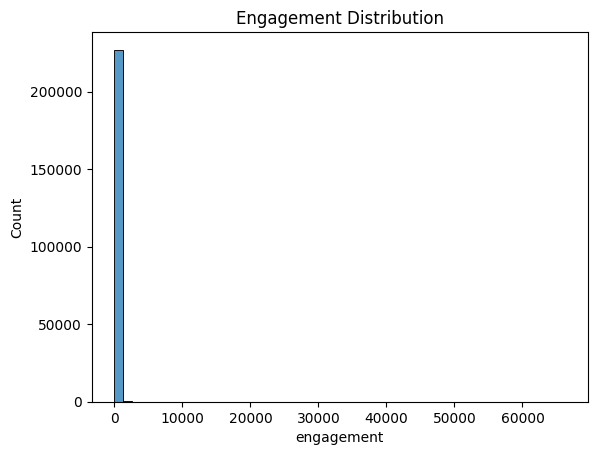

In [14]:
sns.histplot(df['engagement'], bins=50)
plt.title("Engagement Distribution")
plt.show()

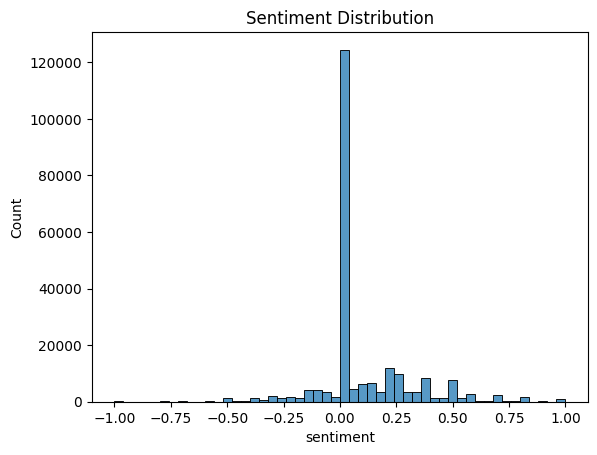

In [15]:
sns.histplot(df['sentiment'], bins=50)
plt.title("Sentiment Distribution")
plt.show()

In [16]:
df.to_csv("processed_vaccine_tweets.csv", index=False)

In [17]:
df[['followers_log','friends_log','engagement','sentiment']].describe()

,followers_log,friends_log,engagement,sentiment
count,227299.000000,227299.000000,227299.000000,227299.000000
mean,5.977025,4.786261,13.341594,0.087846
std,2.772395,2.618758,246.990319,0.223856
min,0.000000,0.000000,0.000000,-1.000000
25%,4.025352,3.295837,0.000000,0.000000
50%,5.796058,5.433722,1.000000,0.000000
75%,7.328437,6.677083,3.000000,0.200000
max,16.609925,13.275019,66311.000000,1.000000


In [18]:
import ast

def parse_hashtags(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return []

df['hashtag_list'] = df['hashtags'].apply(parse_hashtags)